In [1]:
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore")

X_feat = np.load("data/X_features.npy")
Y = np.load("data/Y.npy")
feature_names = list(np.load("data/feature_names.npy"))

print(f"X_feat: {X_feat.shape}")
print(f"Features: {len(feature_names)}")


X_feat: (1947, 95)
Features: 95


In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

classes = np.unique(Y)
weights = compute_class_weight("balanced", classes=classes, y=Y)
class_weight_dict = dict(zip(classes, weights))

clf = SVC(kernel="rbf", C=10, gamma="scale",
          class_weight=class_weight_dict, probability=True, random_state=42)
clf.fit(X_scaled, Y)
print("Model trained on full dataset for SHAP analysis")
print(f"Classes: {clf.classes_}")


Model trained on full dataset for SHAP analysis
Classes: [0 1 2 3]


In [3]:
background_size = min(200, len(X_scaled))
np.random.seed(42)
bg_idx = np.random.choice(len(X_scaled), background_size, replace=False)
background = X_scaled[bg_idx]

explain_size = min(300, len(X_scaled))
explain_idx = np.random.choice(len(X_scaled), explain_size, replace=False)
X_explain = X_scaled[explain_idx]
Y_explain = Y[explain_idx]

explainer = shap.KernelExplainer(clf.predict_proba, background)
print(f"Background samples: {background_size}")
print(f"Explain samples: {explain_size}")
print("Computing SHAP values (this takes a few minutes)...")

shap_values = explainer.shap_values(X_explain, nsamples=100)
print(f"SHAP values shape: {np.array(shap_values).shape}")

np.save("data/shap_values.npy", np.array(shap_values))
np.save("data/X_explain.npy", X_explain)
np.save("data/Y_explain.npy", Y_explain)
print("SHAP values saved")


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Background samples: 200
Explain samples: 300
Computing SHAP values (this takes a few minutes)...


  0%|          | 0/300 [00:00<?, ?it/s]

SHAP values shape: (300, 95, 4)
SHAP values saved


In [4]:
shap_values = np.load("data/shap_values.npy", allow_pickle=True)
X_explain = np.load("data/X_explain.npy")
Y_explain = np.load("data/Y_explain.npy")

label_names = {0: "No Tremor", 1: "Mild", 2: "Moderate", 3: "Severe"}
present_classes = sorted(np.unique(Y_explain))
n_classes = len(present_classes)

mean_abs_shap = {}
for i, cls in enumerate(present_classes):
    if shap_values.ndim == 3:
        sv = shap_values[i]
    else:
        sv = shap_values[:, :, i] if shap_values.shape[2] == n_classes else shap_values[i]
    mean_abs_shap[cls] = np.mean(np.abs(sv), axis=0)

print("Mean |SHAP| computed per class")
for cls in present_classes:
    top5_idx = np.argsort(mean_abs_shap[cls])[-5:][::-1]
    print(f"\nTop 5 features for {label_names[cls]}:")
    for idx in top5_idx:
        print(f"  {feature_names[idx]}: {mean_abs_shap[cls][idx]:.4f}")


Mean |SHAP| computed per class

Top 5 features for No Tremor:
  raw_x_mean: 0.0028
  raw_x_min: 0.0017
  raw_x_std: 0.0006
  raw_x_max: 0.0006

Top 5 features for Mild:
  raw_x_mean: 0.0007
  raw_x_min: 0.0004
  raw_x_std: 0.0002
  raw_x_max: 0.0001

Top 5 features for Moderate:
  raw_x_mean: 0.0040
  raw_x_min: 0.0035
  raw_x_std: 0.0016
  raw_x_max: 0.0005

Top 5 features for Severe:
  raw_x_mean: 0.0007
  raw_x_min: 0.0003
  raw_x_std: 0.0003
  raw_x_max: 0.0002


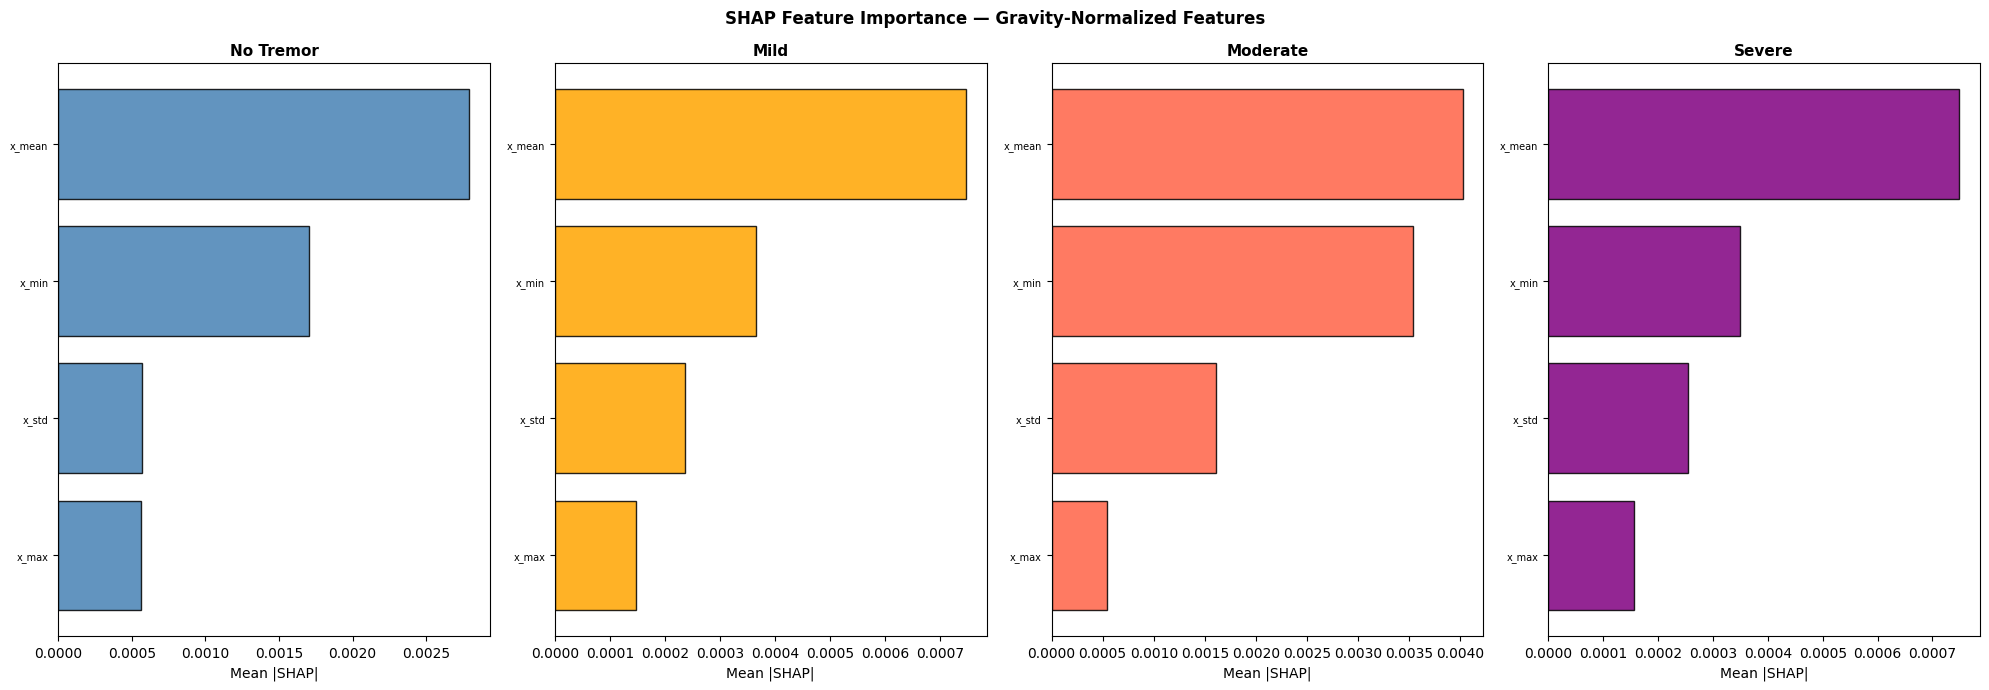

In [6]:
top_n = 15
present_classes = sorted(np.unique(Y_explain))
n_cols = len(present_classes)
fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 7))
if n_cols == 1:
    axes = [axes]

colors_map = {0: "steelblue", 1: "orange", 2: "tomato", 3: "purple"}

for ax, cls in zip(axes, present_classes):
    shap_cls = mean_abs_shap[cls]
    top_idx = np.argsort(shap_cls)[-top_n:]
    top_vals = shap_cls[top_idx]
    top_names = [feature_names[i] for i in top_idx]

    short_names = []
    for n in top_names:
        parts = n.split("_")
        short_names.append("_".join(parts[-2:])[:18])

    ax.barh(np.arange(len(top_vals)), top_vals,
            color=colors_map.get(cls, "gray"), edgecolor="black", alpha=0.85)
    ax.set_yticks(np.arange(len(top_vals)))
    ax.set_yticklabels(short_names, fontsize=7)
    ax.set_title(f"{label_names[cls]}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean |SHAP|")

plt.suptitle("SHAP Feature Importance — Gravity-Normalized Features",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/04_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

No Tremor: gravity=0.000, dynamic=0.000, raw=1.000
Mild: gravity=0.000, dynamic=0.000, raw=1.000
Moderate: gravity=0.000, dynamic=0.000, raw=1.000
Severe: gravity=0.000, dynamic=0.000, raw=1.000


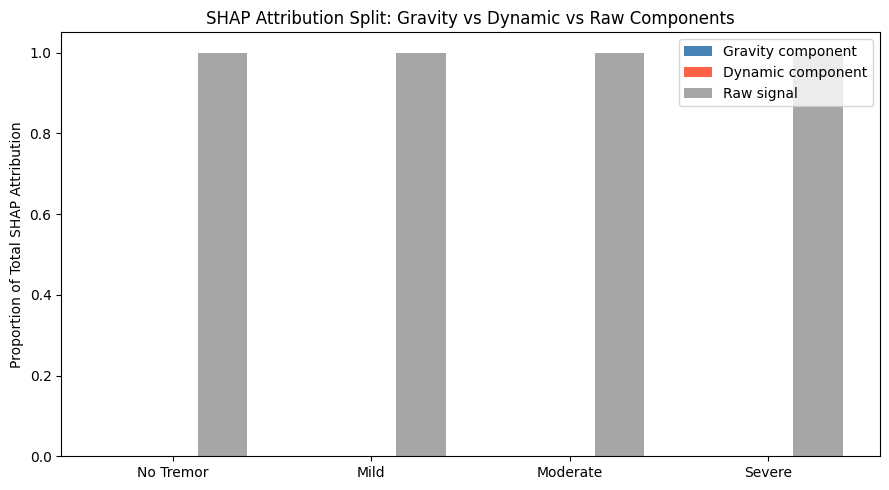

In [8]:
results = {}
for cls in present_classes:
    if shap_values.ndim == 3:
        sv_full = shap_values[list(present_classes).index(cls)]
    else:
        sv_full = shap_values[:, :, list(present_classes).index(cls)]
    mean_sv = np.mean(np.abs(sv_full), axis=0)
    total = mean_sv.sum()
    grav_sum = sum(mean_sv[i] for i, n in enumerate(feature_names) if i < len(mean_sv) and "grav_" in n)
    dyn_sum = sum(mean_sv[i] for i, n in enumerate(feature_names) if i < len(mean_sv) and "dyn_" in n)
    raw_sum = sum(mean_sv[i] for i, n in enumerate(feature_names) if i < len(mean_sv) and "raw_" in n)
    results[cls] = {"gravity": grav_sum/total, "dynamic": dyn_sum/total, "raw": raw_sum/total}
    print(f"{label_names[cls]}: gravity={grav_sum/total:.3f}, dynamic={dyn_sum/total:.3f}, raw={raw_sum/total:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(present_classes))
w = 0.25
ax.bar(x - w, [results[c]["gravity"] for c in present_classes], w, label="Gravity component", color="steelblue")
ax.bar(x,     [results[c]["dynamic"] for c in present_classes], w, label="Dynamic component", color="tomato")
ax.bar(x + w, [results[c]["raw"]     for c in present_classes], w, label="Raw signal", color="gray", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([label_names[c] for c in present_classes])
ax.set_ylabel("Proportion of Total SHAP Attribution")
ax.set_title("SHAP Attribution Split: Gravity vs Dynamic vs Raw Components")
ax.legend()
plt.tight_layout()
plt.savefig("figures/04_shap_component_split.png", dpi=150, bbox_inches="tight")
plt.show()